In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("antonkozyriev/game-recommendations-on-steam")
print("Path to dataset files:", path)


games_raw = pd.read_csv(os.path.join(path, "games.csv"))
users_raw = pd.read_csv(os.path.join(path, "users.csv"))
recommendations_raw = pd.read_csv(os.path.join(path, "recommendations.csv"))


games_df = games_raw.copy()

interactions_df = recommendations_raw.merge(users_raw, on="user_id", how="left")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/aregayvazyan/.cache/kagglehub/datasets/antonkozyriev/game-recommendations-on-steam/versions/28


In [2]:
print("games_df:", games_df.shape)
games_df.head()

games_df: (50872, 13)


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


In [3]:
print("interactions_df:", interactions_df.shape)
interactions_df.head()

interactions_df: (41154794, 10)


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id,products,reviews
0,975370,0,0,2022-12-12,True,36.3,51580,0,28,5
1,304390,4,0,2017-02-17,False,11.5,2586,1,269,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2,237,2
3,703080,0,0,2022-09-23,True,27.4,259432,3,5,2
4,526870,0,0,2021-01-10,True,7.9,23869,4,13,2


In [4]:
def data_quality_report(df, name):
    print(f"\n{'='*50}")
    print(f"DATA QUALITY REPORT: {name}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "n_missing": df.isnull().sum(),
        "pct_missing": (df.isnull().sum() / len(df) * 100).round(2),
        "n_unique": df.nunique()
    })
    print(report)
    return report


games_report = data_quality_report(games_df, "games_df")
interactions_report = data_quality_report(interactions_df, "interactions_df")


DATA QUALITY REPORT: games_df
Shape: (50872, 13)
Duplicate rows: 0
                  dtype  n_missing  pct_missing  n_unique
app_id            int64          0          0.0     50872
title            object          0          0.0     50751
date_release     object          0          0.0      4292
win                bool          0          0.0         2
mac                bool          0          0.0         2
linux              bool          0          0.0         2
rating           object          0          0.0         9
positive_ratio    int64          0          0.0       100
user_reviews      int64          0          0.0      4847
price_final     float64          0          0.0       436
price_original  float64          0          0.0       183
discount        float64          0          0.0        75
steam_deck         bool          0          0.0         2

DATA QUALITY REPORT: interactions_df
Shape: (41154794, 10)
Duplicate rows: 0
                  dtype  n_missing  pct_mi

In [5]:
# ---------------------------------------------------------
# games_df specific checks
# ---------------------------------------------------------
print("Duplicate app_id in games_df:", games_df["app_id"].duplicated().sum())
print("Negative or zero prices:", (games_df["price_final"] < 0).sum())
print("Price_final > price_original (should be rare/never):",
      (games_df["price_final"] > games_df["price_original"]).sum())


# ---------------------------------------------------------
# interactions_df specific checks
# ---------------------------------------------------------
print("\nMissing user_id or app_id (should be 0):",
      interactions_df[["user_id", "app_id"]].isnull().sum().sum())

print("Negative hours played:", (interactions_df["hours"] < 0).sum())
print("Zero hours played (reviewed but never played?):",
      (interactions_df["hours"] == 0).sum())

print("Duplicate review_id:", interactions_df["review_id"].duplicated().sum())

print("is_recommended value counts:")
print(interactions_df["is_recommended"].value_counts(dropna=False))

# Date range sanity check
interactions_df["date"] = pd.to_datetime(interactions_df["date"], errors="coerce")
print("\nInvalid/unparseable dates:", interactions_df["date"].isnull().sum())
print("Date range:", interactions_df["date"].min(), "to", interactions_df["date"].max())

# Check app_ids in interactions_df that don't exist in games_df (orphan records)
orphan_games = ~interactions_df["app_id"].isin(games_df["app_id"])
print("\nInteractions referencing app_id not in games_df:", orphan_games.sum())

# Check users with unusually high review counts (potential bots/outliers)
print("\nProducts/reviews distribution (from merged users_raw):")
print(interactions_df[["products", "reviews"]].describe())

Duplicate app_id in games_df: 0
Negative or zero prices: 0
Price_final > price_original (should be rare/never): 985

Missing user_id or app_id (should be 0): 0
Negative hours played: 0
Zero hours played (reviewed but never played?): 176329
Duplicate review_id: 0
is_recommended value counts:
is_recommended
True     35304398
False     5850396
Name: count, dtype: int64

Invalid/unparseable dates: 0
Date range: 2010-10-15 00:00:00 to 2022-12-31 00:00:00

Interactions referencing app_id not in games_df: 0

Products/reviews distribution (from merged users_raw):
           products       reviews
count  4.115479e+07  4.115479e+07
mean   2.820449e+02  2.505425e+01
std    6.647377e+02  1.398683e+02
min    0.000000e+00  1.000000e+00
25%    5.000000e+01  2.000000e+00
50%    1.190000e+02  5.000000e+00
75%    2.720000e+02  1.500000e+01
max    3.221400e+04  6.045000e+03


/var/folders/f6/zss0c7mn18z86b0_3p39wb500000gn/T/ipykernel_3623/3297126200.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_games, y="title", x="user_reviews", palette="viridis")


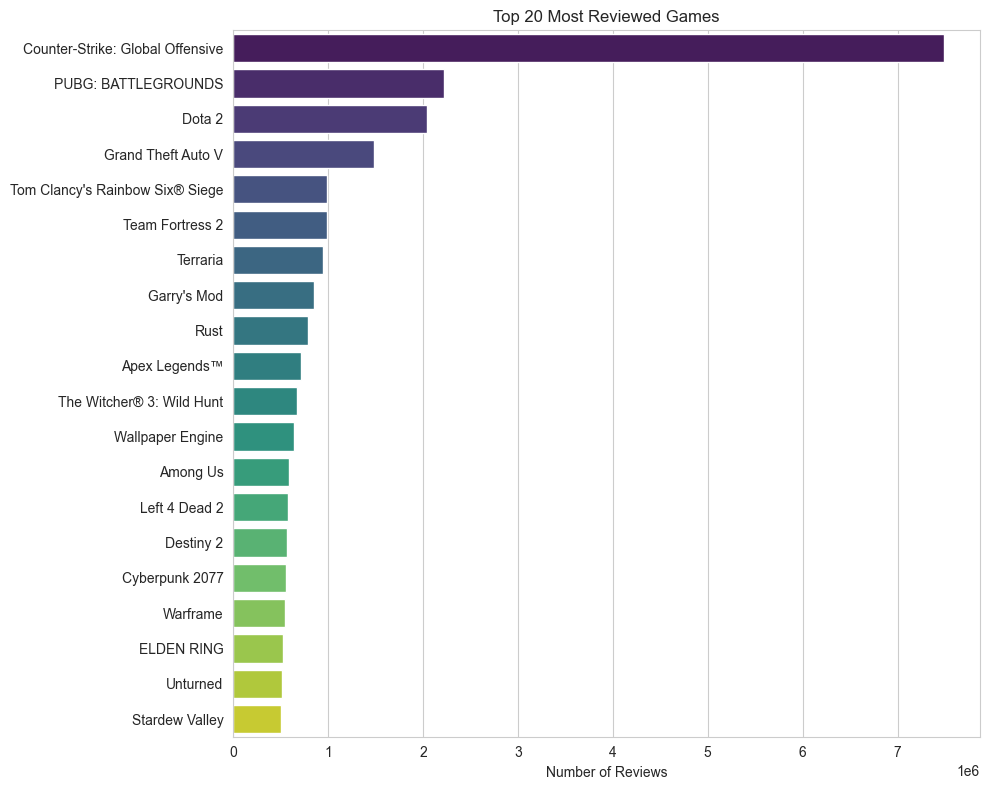

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid")

#print top 20 games
top_games = games_df.nlargest(20, "user_reviews")

plt.figure(figsize=(10, 8))
sns.barplot(data=top_games, y="title", x="user_reviews", palette="viridis")
plt.title("Top 20 Most Reviewed Games")
plt.xlabel("Number of Reviews")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/f6/zss0c7mn18z86b0_3p39wb500000gn/T/ipykernel_3623/2700259216.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=games_df, y="rating", order=order, palette="mako")


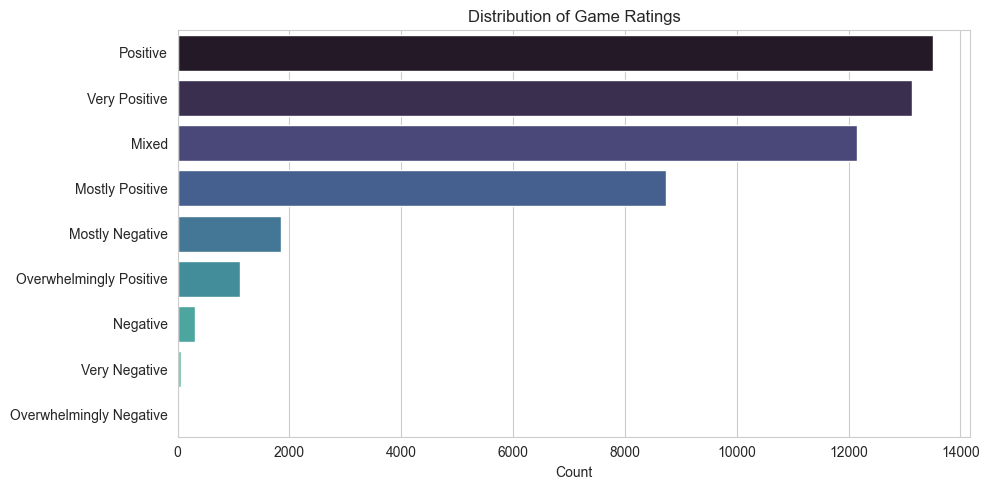

In [7]:
# ---------------------------------------------------------
# 3. Rating category distribution
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
order = games_df["rating"].value_counts().index
sns.countplot(data=games_df, y="rating", order=order, palette="mako")
plt.title("Distribution of Game Ratings")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

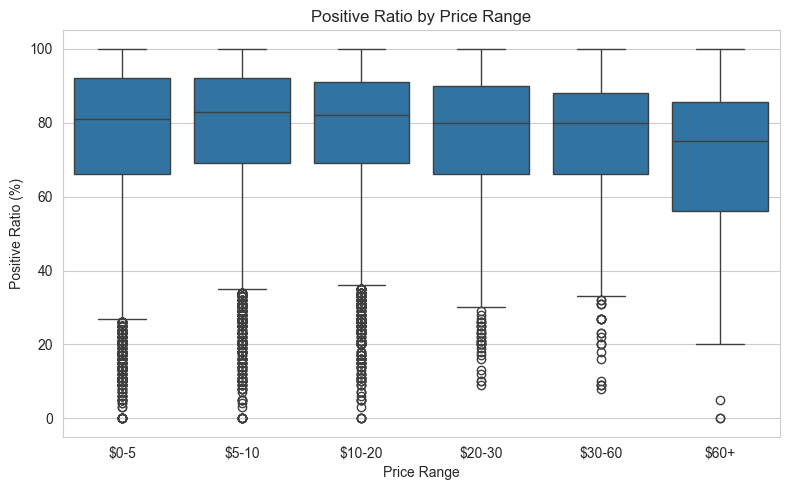

In [15]:
# ---------------------------------------------------------
# 4. Price vs positive_ratio scatter
# ---------------------------------------------------------
games_df["price_bucket"] = pd.cut(
    games_df["price_final"],
    bins=[0, 5, 10, 20, 30, 60, np.inf],
    labels=["$0-5", "$5-10", "$10-20", "$20-30", "$30-60", "$60+"]
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=games_df, x="price_bucket", y="positive_ratio")
plt.title("Positive Ratio by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Positive Ratio (%)")
plt.tight_layout()
plt.show()

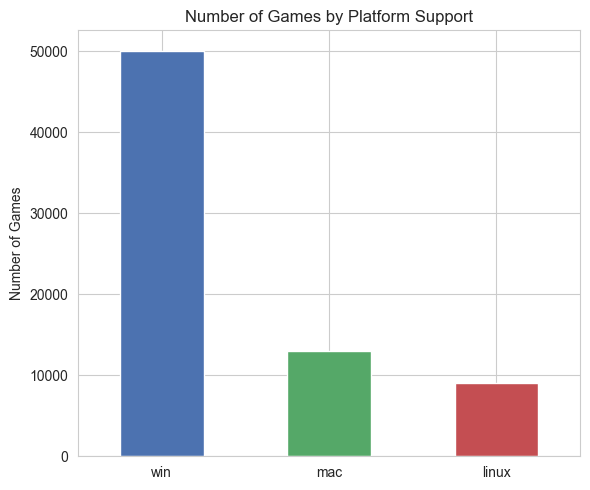

In [9]:
platform_counts = games_df[["win", "mac", "linux"]].sum()

plt.figure(figsize=(6, 5))
platform_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Number of Games by Platform Support")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

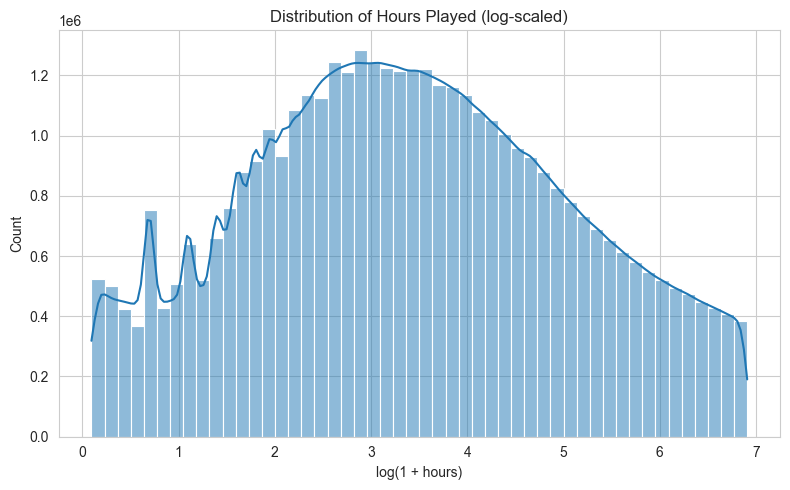

In [10]:
# ---------------------------------------------------------
# 6. Distribution of hours played (log scale, since heavily skewed)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
hours_nonzero = interactions_df.loc[interactions_df["hours"] > 0, "hours"]
sns.histplot(np.log1p(hours_nonzero), bins=50, kde=True)
plt.title("Distribution of Hours Played (log-scaled)")
plt.xlabel("log(1 + hours)")
plt.tight_layout()
plt.show()

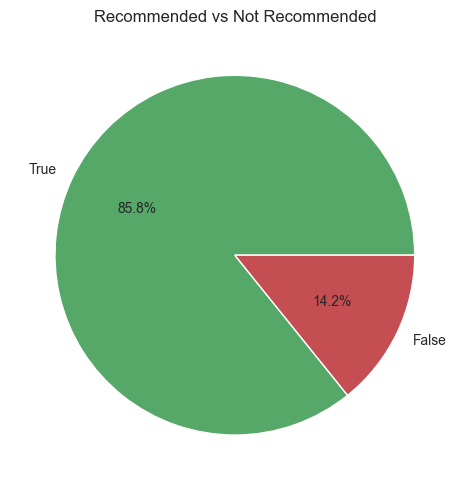

In [11]:
# ---------------------------------------------------------
# 7. is_recommended breakdown
# ---------------------------------------------------------
plt.figure(figsize=(5, 5))
interactions_df["is_recommended"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#55A868", "#C44E52"]
)
plt.title("Recommended vs Not Recommended")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/f6/zss0c7mn18z86b0_3p39wb500000gn/T/ipykernel_3623/28664037.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  reviews_over_time = interactions_df.set_index("date").resample("M").size()


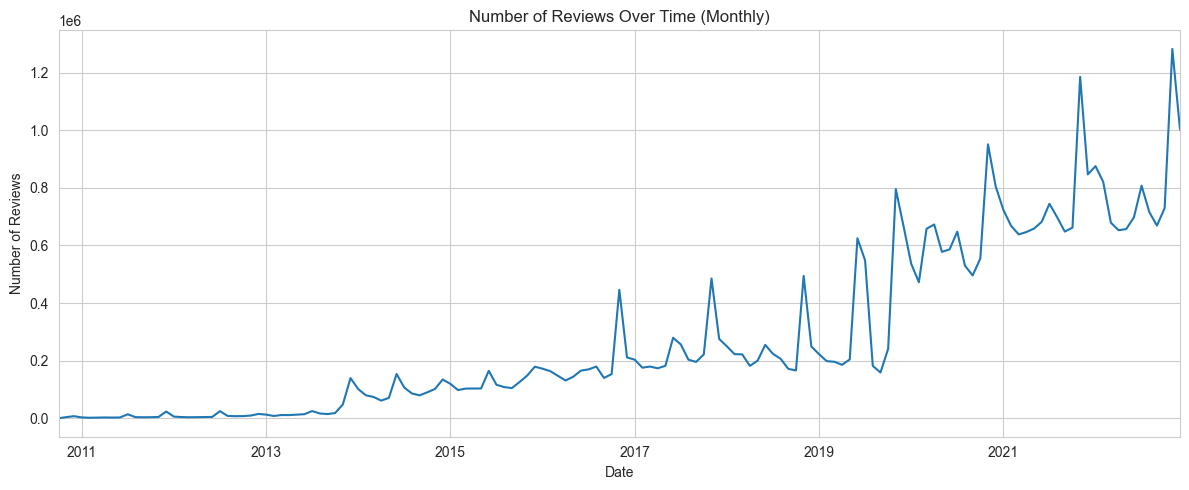

In [12]:
# ---------------------------------------------------------
# 8. Review volume over time
# ---------------------------------------------------------
interactions_df["date"] = pd.to_datetime(interactions_df["date"], errors="coerce")
reviews_over_time = interactions_df.set_index("date").resample("M").size()

plt.figure(figsize=(12, 5))
reviews_over_time.plot()
plt.title("Number of Reviews Over Time (Monthly)")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


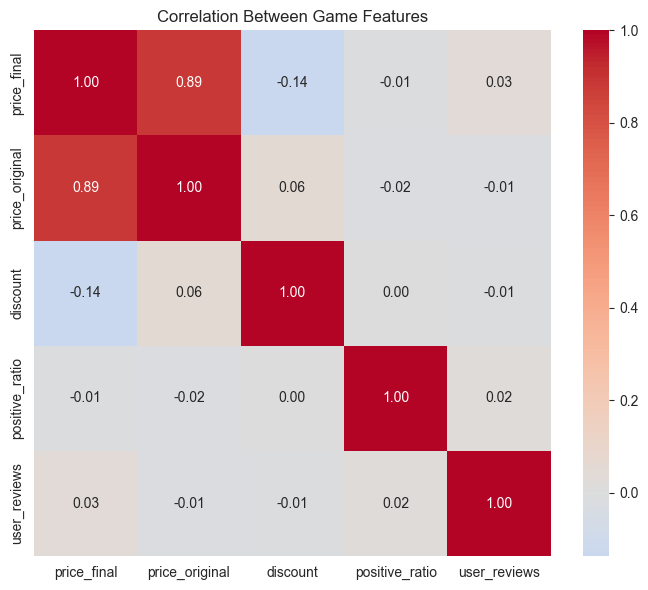

In [13]:
# ---------------------------------------------------------
# 9. Correlation heatmap (numeric game features)
# ---------------------------------------------------------
numeric_cols = ["price_final", "price_original", "discount", "positive_ratio", "user_reviews"]
corr = games_df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Game Features")
plt.tight_layout()
plt.show()

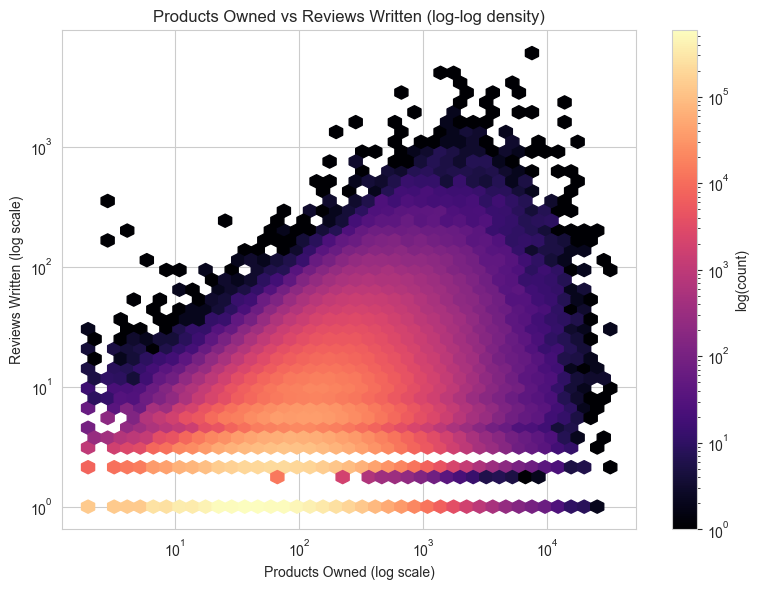

In [17]:
user_activity = interactions_df.drop_duplicates("user_id")[["products", "reviews"]]
user_activity = user_activity[(user_activity["products"] > 0) & (user_activity["reviews"] > 0)]

plt.figure(figsize=(8, 6))
plt.hexbin(
    user_activity["products"], 
    user_activity["reviews"],
    gridsize=40, 
    cmap="magma", 
    bins="log",       # log-scales the COLOR (count) axis
    xscale="log",     # log-scales the X data axis (inside hexbin, not after)
    yscale="log",     # log-scales the Y data axis (inside hexbin, not after)
    mincnt=1
)
plt.colorbar(label="log(count)")
plt.title("Products Owned vs Reviews Written (log-log density)")
plt.xlabel("Products Owned (log scale)")
plt.ylabel("Reviews Written (log scale)")
plt.tight_layout()
plt.show()